<a href="https://colab.research.google.com/github/ChumakOleksandr/ITStep-AI/blob/superwised_learning/%D0%94%D0%97_%D0%BE%D0%B1%D1%80%D0%BE%D0%B1%D0%BA%D0%B0_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module3/data/House_Rent_Dataset.csv", index_col="Unnamed: 0")

[Інформація про дані](https://www.kaggle.com/datasets/iamsouravbanerjee/house-rent-prediction-dataset)

In [3]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2.0,10000.0,1100.0,Ground out of 2,NaN,NaN,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
1,2022-05-13,2.0,20000.0,800.0,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1.0,NaN
2,2022-05-16,2.0,17000.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,2022-07-04,2.0,10000.0,800.0,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,NaN,2.0,7500.0,850.0,1 out of 2,Carpet Area,NaN,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner


# Завдання 1
Виведіть інформацію про таблицю(кількість рядків та стовпчиків та типи даних). Також виведіть кількість пропущених значень по стовпчиках

In [4]:
df.select_dtypes(include='number').columns

Index(['BHK', 'Rent', 'Size', 'Bathroom'], dtype='object')

In [5]:
print("Количество строк и столбцов:", df.shape)

df.info()

print("\nКоличество пропусков:")
print(df.isnull().sum())

Количество строк и столбцов: (4746, 12)
<class 'pandas.core.frame.DataFrame'>
Index: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Posted On          4379 non-null   object 
 1   BHK                4342 non-null   float64
 2   Rent               4369 non-null   float64
 3   Size               4402 non-null   float64
 4   Floor              4380 non-null   object 
 5   Area Type          4390 non-null   object 
 6   Area Locality      4347 non-null   object 
 7   City               4388 non-null   object 
 8   Furnishing Status  4395 non-null   object 
 9   Tenant Preferred   4372 non-null   object 
 10  Bathroom           4387 non-null   float64
 11  Point of Contact   4372 non-null   object 
dtypes: float64(4), object(8)
memory usage: 611.1+ KB

Количество пропусков:
Posted On            367
BHK                  404
Rent                 377
Size                 344
Floor    

In [14]:
cleaned_df = df.copy()

# Завдання 2
Виведіть гістограми для всіх числових стовпчиків

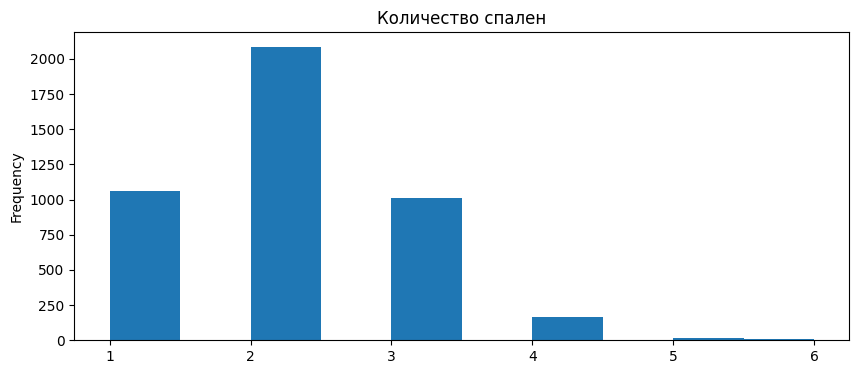

In [6]:
df['BHK'].plot(kind='hist', bins=10, figsize=(10, 4))
plt.title('Количество спален')
plt.show()

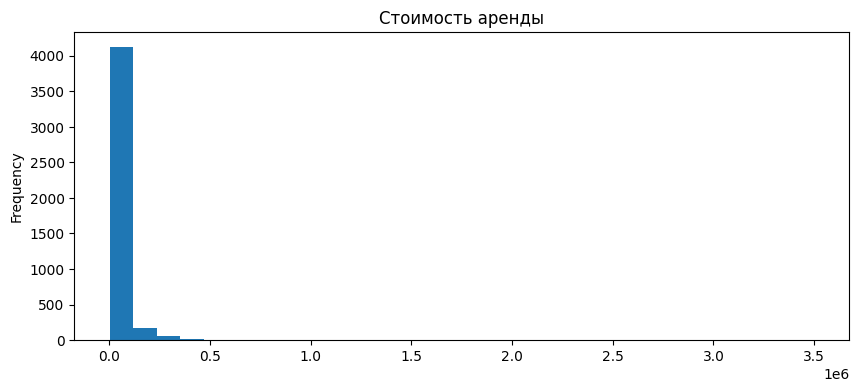

In [7]:
df['Rent'].plot(kind='hist', bins=30, figsize=(10, 4))
plt.title('Стоимость аренды')
plt.show()

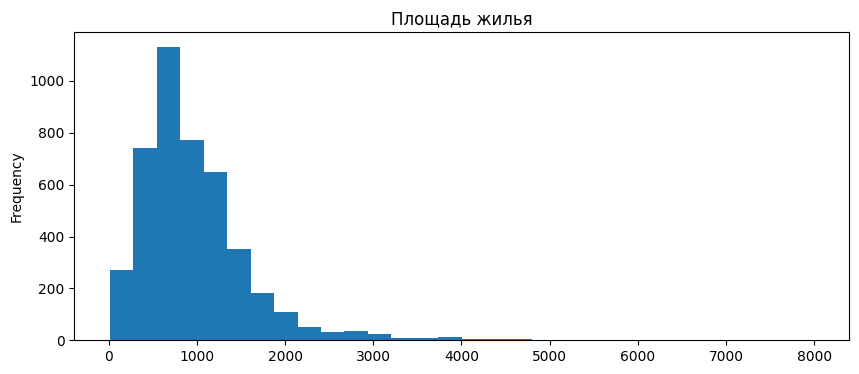

In [8]:
df['Size'].plot(kind='hist', bins=30, figsize=(10, 4))
plt.title('Площадь жилья')
plt.show()

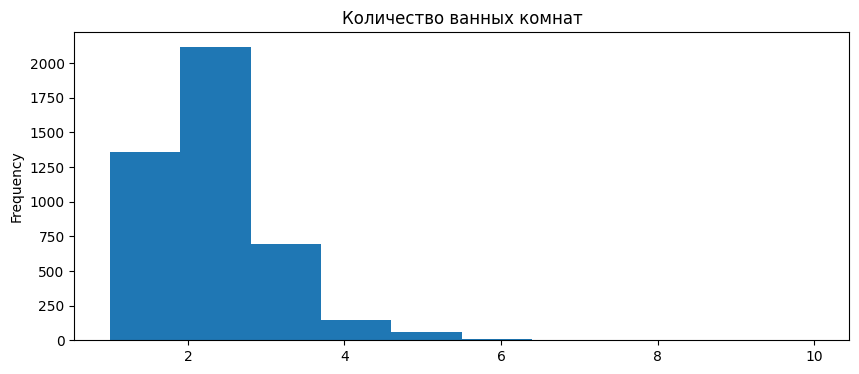

In [9]:
df['Bathroom'].plot(kind='hist', bins=10, figsize=(10, 4))
plt.title('Количество ванных комнат')
plt.show()

# Завдання 3
Виведіть ящик з вусами для всіх числових стовпчиків. Де потрібно очистіть викиди

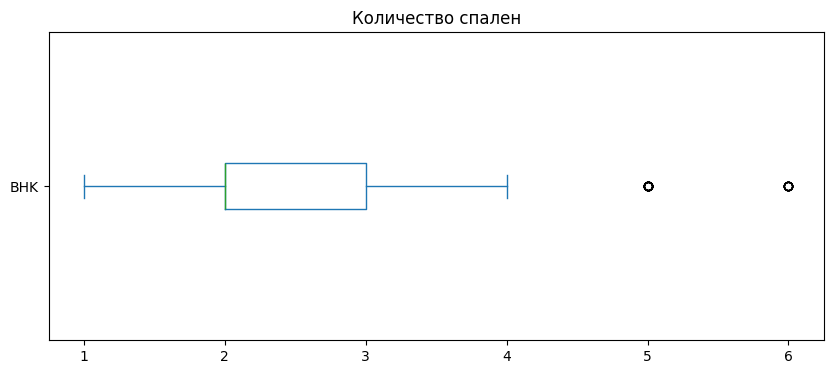

In [10]:
df['BHK'].plot(kind='box', vert=False, figsize=(10, 4))
plt.title('Количество спален')
plt.show()

In [15]:
column = cleaned_df['Rent']

q1 = column.quantile(q=0.25)
q3 = column.quantile(q=0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

mask = (column >= lower) & (column <= upper)

print("До очистки:", cleaned_df.shape)

cleaned_df = cleaned_df[mask | column.isnull()].copy()

print("После очистки:", cleaned_df.shape)

До очистки: (4746, 12)
После очистки: (4272, 12)


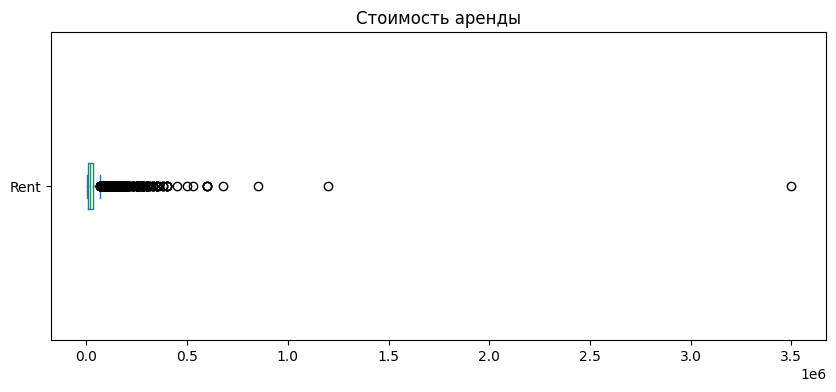

In [11]:
df['Rent'].plot(kind='box', vert=False, figsize=(10, 4))
plt.title('Стоимость аренды')
plt.show()

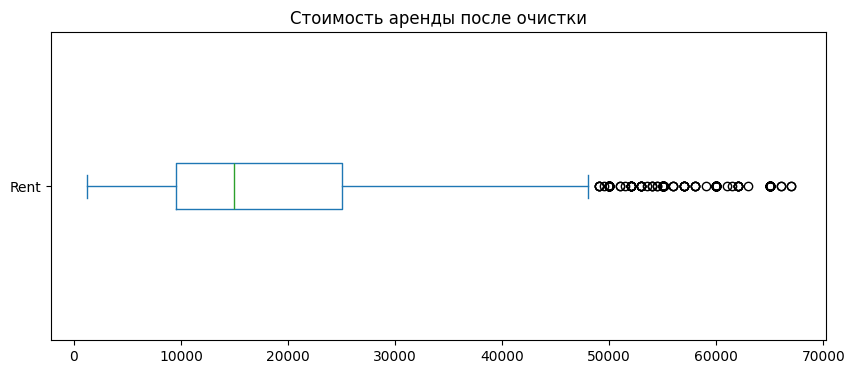

In [16]:
cleaned_df['Rent'].plot(kind='box', vert=False, figsize=(10, 4))
plt.title('Стоимость аренды после очистки')
plt.show()

In [17]:
column = cleaned_df['Size']

q1 = column.quantile(q=0.25)
q3 = column.quantile(q=0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

mask = (column >= lower) & (column <= upper)

print("До очистки:", cleaned_df.shape)

cleaned_df = cleaned_df[mask | column.isnull()].copy()

print("После очистки:", cleaned_df.shape)

До очистки: (4272, 12)
После очистки: (4142, 12)


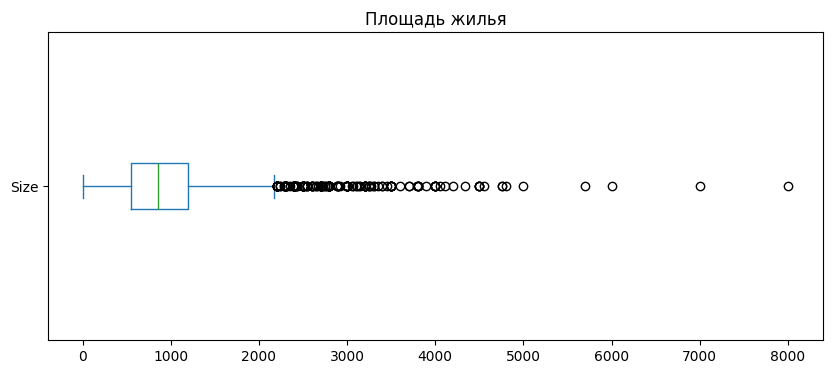

In [12]:
df['Size'].plot(kind='box', vert=False, figsize=(10, 4))
plt.title('Площадь жилья')
plt.show()

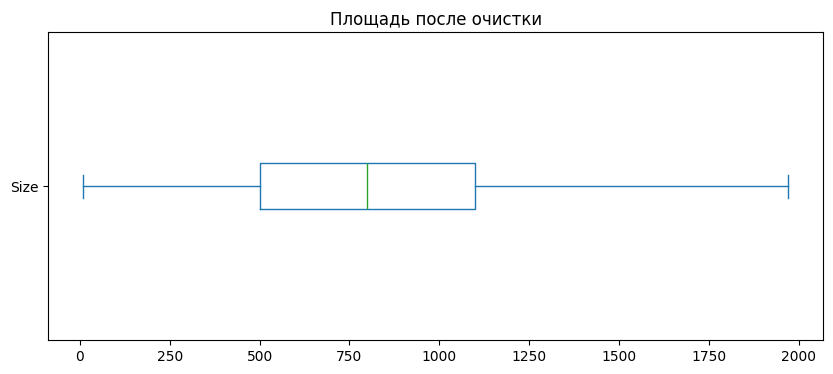

In [18]:
cleaned_df['Size'].plot(kind='box', vert=False, figsize=(10, 4))
plt.title('Площадь после очистки')
plt.show()

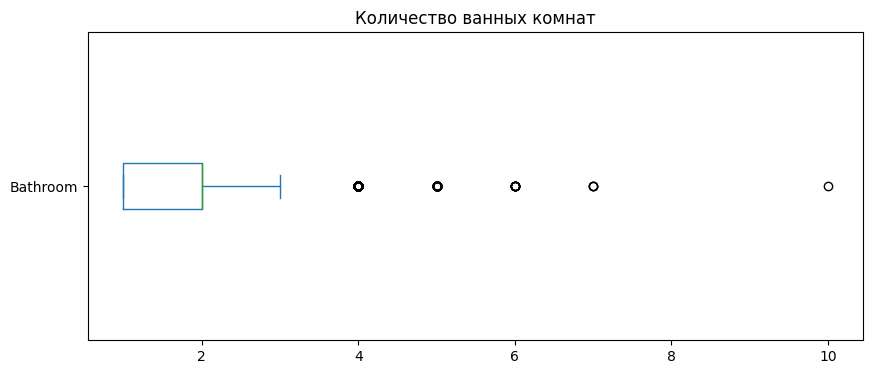

In [13]:
df['Bathroom'].plot(kind='box', vert=False, figsize=(10, 4))
plt.title('Количество ванных комнат')
plt.show()

# Завдання 4
Створіть Pipeline для обробки даних